In [20]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import SimpleITK as sitk
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from matplotlib.patches import Rectangle

from NoduleDS import NoduleDataset

print("✓ All imports successful", flush=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMAGE_SIZE = 224
BASE_WIDTH_PX = 1100
DPI = 300
SPLIT_BASE_PATH = Path('./dataset_nodule21/cxr_images/proccessed_data/split_data')
MODEL_A_PATH = './resnet50_binary.pth'
MODEL_B_PATH = './attention_resnet50.pth'
TARGET_PATIENTS = ['n0282.mha', 'n0368.mha']

print(f"✓ Constants set. DEVICE={DEVICE}", flush=True)


class SpatialAttentionModule(nn.Module):
    def __init__(self, in_channels=2048, reduction=8):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels // reduction, kernel_size=1)
        self.bn1 = nn.BatchNorm2d(in_channels // reduction)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(in_channels // reduction, in_channels // reduction, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(in_channels // reduction)
        self.conv_out = nn.Conv2d(in_channels // reduction, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        att = self.relu(self.bn1(self.conv1(x)))
        att = self.relu(self.bn2(self.conv2(att)))
        attention = self.sigmoid(self.conv_out(att))
        weighted_features = x * attention
        return attention, weighted_features


class WSODModelWithAttention(nn.Module):
    def __init__(self, base_model, num_classes=2, freeze_backbone=True):
        super().__init__()
        if freeze_backbone:
            for param in base_model.parameters():
                param.requires_grad = False
        self.features = nn.Sequential(*list(base_model.children())[:-2])
        self.avgpool = list(base_model.children())[-2]
        self.spatial_attention = SpatialAttentionModule(in_channels=2048)
        self.fc = nn.Linear(2048, num_classes)

        original_fc = list(base_model.children())[-1]
        if isinstance(original_fc, nn.Linear):
            self.fc.weight.data.copy_(original_fc.weight.data)
            self.fc.bias.data.copy_(original_fc.bias.data)

    def forward(self, x, return_attention=False):
        features = self.features(x)
        attention_map, weighted_features = self.spatial_attention(features)
        pooled = self.avgpool(weighted_features).flatten(1)
        output = self.fc(pooled)
        if return_attention:
            return output, attention_map
        return output

    def get_attention_map(self, x):
        with torch.no_grad():
            features = self.features(x)
            attention_map, _ = self.spatial_attention(features)
        return attention_map


class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_handle = target_layer.register_forward_hook(self._forward_hook)
        self.backward_handle = target_layer.register_full_backward_hook(self._backward_hook)

    def _forward_hook(self, module, inputs, output):
        self.activations = output

    def _backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, input_tensor, target_class=1):
        self.model.zero_grad(set_to_none=True)
        logits = self.model(input_tensor)
        score = logits[:, target_class].sum()
        score.backward(retain_graph=False)

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[-2:], mode='bilinear', align_corners=False)
        cam = cam[0, 0].detach().cpu().numpy()
        cam -= cam.min()
        cam /= cam.max() + 1e-8
        return cam

    def close(self):
        self.forward_handle.remove()
        self.backward_handle.remove()

print("✓ Class definitions done", flush=True)

# --- CSV loading ---
print("Loading CSVs...", flush=True)
train_csv = SPLIT_BASE_PATH / 'train' / 'metadata_train.csv'
val_csv = SPLIT_BASE_PATH / 'val' / 'metadata_val.csv'
test_csv = SPLIT_BASE_PATH / 'test' / 'metadata_test.csv'

print(f"  Reading train CSV: {train_csv}", flush=True)
train_df = pd.read_csv(train_csv)
print(f"  ✓ train_df loaded ({len(train_df)} rows)", flush=True)

print(f"  Reading val CSV: {val_csv}", flush=True)
val_df = pd.read_csv(val_csv)
print(f"  ✓ val_df loaded ({len(val_df)} rows)", flush=True)

print(f"  Reading test CSV: {test_csv}", flush=True)
test_df = pd.read_csv(test_csv)
print(f"  ✓ test_df loaded ({len(test_df)} rows)", flush=True)

combined_df = pd.concat([
    train_df.assign(split='train'),
    val_df.assign(split='val'),
    test_df.assign(split='test'),
], ignore_index=True)
print(f"✓ combined_df ready ({len(combined_df)} rows)", flush=True)

transform_inference = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
print("✓ Transform defined", flush=True)


def load_checkpoint(model, checkpoint_path):
    print(f"  torch.load: {checkpoint_path}...", flush=True)
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
    print(f"  ✓ Checkpoint file read", flush=True)
    if isinstance(checkpoint, dict):
        for key in ('model_state_dict', 'state_dict'):
            if key in checkpoint:
                checkpoint = checkpoint[key]
                break
    if isinstance(checkpoint, dict) and any(key.startswith('module.') for key in checkpoint.keys()):
        checkpoint = {key.replace('module.', '', 1): value for key, value in checkpoint.items()}
    missing, unexpected = model.load_state_dict(checkpoint, strict=False)
    if missing or unexpected:
        print(f'  Loaded {checkpoint_path} with missing={missing} unexpected={unexpected}', flush=True)
    else:
        print(f'  ✓ Loaded {checkpoint_path} cleanly', flush=True)
    return model


# --- Model A ---
print("Creating base_model_a via timm...", flush=True)
base_model_a = timm.create_model('resnet50', pretrained=False, num_classes=2)
print("✓ base_model_a created", flush=True)

print("Loading checkpoint for model_a...", flush=True)
model_a = load_checkpoint(base_model_a.to(DEVICE), MODEL_A_PATH).eval()
print("✓ model_a ready", flush=True)

print("Attaching GradCAM to model_a...", flush=True)
cam_a = GradCAM(model_a, model_a.layer4[-1])
print("✓ GradCAM attached", flush=True)

# --- Model B ---
print("Creating base_model_b via timm...", flush=True)
base_model_b = timm.create_model('resnet50', pretrained=False, num_classes=2)
print("✓ base_model_b created", flush=True)

print("Wrapping base_model_b in WSODModelWithAttention...", flush=True)
model_b = WSODModelWithAttention(base_model_b, num_classes=2, freeze_backbone=True).to(DEVICE)
print("✓ model_b wrapped", flush=True)

print("Loading checkpoint for model_b...", flush=True)
model_b = load_checkpoint(model_b, MODEL_B_PATH).eval()
print("✓ model_b ready", flush=True)


def find_patient_record(patient_name):
    exact = combined_df[combined_df['img_name'] == patient_name]
    if not exact.empty:
        return exact.iloc[0]

    patient_stem = Path(patient_name).stem
    matches = combined_df[combined_df['img_name'].str.contains(patient_stem, regex=False, na=False)]
    if matches.empty:
        raise ValueError(f'No metadata row found for {patient_name}')
    return matches.iloc[0]


def load_patient_sample(patient_name):
    print(f"  Finding record for {patient_name}...", flush=True)
    row = find_patient_record(patient_name)
    split_dir = SPLIT_BASE_PATH / row['split'] / 'images'
    image_path = split_dir / row['img_name']
    print(f"  Found at {image_path}", flush=True)

    print(f"  sitk.ReadImage...", flush=True)
    image = sitk.ReadImage(str(image_path))
    print(f"  ✓ sitk.ReadImage done", flush=True)

    image_array = sitk.GetArrayFromImage(image)
    if image_array.ndim == 3:
        image_array = image_array[0]

    original_height, original_width = image_array.shape
    image_array = image_array.astype(np.float32)
    image_min, image_max = image_array.min(), image_array.max()
    if image_max > image_min:
        image_array = ((image_array - image_min) / (image_max - image_min) * 255).astype(np.uint8)
    else:
        image_array = np.zeros_like(image_array, dtype=np.uint8)

    image_rgb = np.stack([image_array, image_array, image_array], axis=-1)
    pil_image = transforms.functional.to_pil_image(image_rgb)
    input_tensor = transform_inference(pil_image).unsqueeze(0)
    print(f"  ✓ Image preprocessed, tensor shape={input_tensor.shape}", flush=True)

    patient_rows = combined_df[combined_df['img_name'] == row['img_name']].copy()
    if patient_rows.empty:
        patient_rows = combined_df[combined_df['img_name'].str.contains(Path(patient_name).stem, regex=False, na=False)].copy()

    bboxes = []
    for _, bbox_row in patient_rows.iterrows():
        if int(bbox_row['label']) != 1:
            continue
        x = float(bbox_row['x']) / original_width
        y = float(bbox_row['y']) / original_height
        w = float(bbox_row['width']) / original_width
        h = float(bbox_row['height']) / original_height
        bboxes.append((x * IMAGE_SIZE, y * IMAGE_SIZE, w * IMAGE_SIZE, h * IMAGE_SIZE))
    print(f"  ✓ {len(bboxes)} bboxes parsed", flush=True)

    return {
        'patient_name': patient_name,
        'image_path': image_path,
        'label': int(row['label']),
        'input_tensor': input_tensor.to(DEVICE),
        'display_image': (input_tensor[0].cpu() * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)).permute(1, 2, 0),  # <-- this line
        'bboxes': bboxes,
    }


def overlay_bboxes(ax, bboxes):
    for x, y, w, h in bboxes:
        ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor='lime', linewidth=0.8))


def heatmap_overlay(image_rgb, heatmap, bboxes, title):
    fig, ax = plt.subplots(figsize=(BASE_WIDTH_PX / DPI, 3.4), dpi=DPI)
    ax.imshow(image_rgb)
    ax.imshow(heatmap, cmap='jet', alpha=0.45, vmin=0.0, vmax=1.0)
    overlay_bboxes(ax, bboxes)
    ax.set_title(title, fontsize=5)
    ax.axis('off')
    return fig


def plot_patient_comparison(patient_name):
    from matplotlib.lines import Line2D

    print(f"\n--- plot_patient_comparison: {patient_name} ---", flush=True)
    sample = load_patient_sample(patient_name)
    input_tensor = sample['input_tensor']
    image_rgb = sample['display_image'].clamp(0, 1).numpy()
    bboxes = sample['bboxes']

    print("  Running GradCAM (model_a)...", flush=True)
    gradcam_map = cam_a(input_tensor, target_class=1)
    print("  ✓ GradCAM done", flush=True)

    print("  Running attention map (model_b)...", flush=True)
    with torch.no_grad():
        attention_map = model_b.get_attention_map(input_tensor).detach()
        attention_map = F.interpolate(attention_map, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)
        attention_map = attention_map[0, 0].cpu().numpy()
        attention_map -= attention_map.min()
        attention_map /= attention_map.max() + 1e-8
    print("  ✓ Attention map done", flush=True)

    print("  Plotting...", flush=True)
    fig, axes = plt.subplots(1, 3, figsize=(BASE_WIDTH_PX / DPI, 3.8), dpi=DPI)
    fig.subplots_adjust(left=0.01, right=0.99, top=0.92, bottom=0.04, wspace=0.02)

    legend_handle = [Line2D([0], [0], color='lime', linewidth=0.8, label='GT BBox')]

    axes[0].imshow(image_rgb)
    overlay_bboxes(axes[0], bboxes)
    axes[0].set_title(patient_name, fontsize=5)
    axes[0].axis('off')
    axes[0].legend(handles=legend_handle, loc='lower right', fontsize=4, framealpha=0.4)

    axes[1].imshow(image_rgb)
    axes[1].imshow(gradcam_map, cmap='jet', alpha=0.45, vmin=0.0, vmax=1.0)
    overlay_bboxes(axes[1], bboxes)
    axes[1].set_title('ResNet-50 Attention', fontsize=5)
    axes[1].axis('off')

    axes[2].imshow(image_rgb)
    axes[2].imshow(attention_map, cmap='jet', alpha=0.45, vmin=0.0, vmax=1.0)
    overlay_bboxes(axes[2], bboxes)
    axes[2].set_title('RNNet-MST Attention', fontsize=5)
    axes[2].axis('off')

    fig.savefig(f'{patient_name}_comparison.png', dpi=DPI, bbox_inches='tight')
    plt.show()
    print("  ✓ Plot shown", flush=True)
    return fig


print('\n✓ Ready. Run plot_patient_comparison(patient_name) to begin.', flush=True)

✓ All imports successful
✓ Constants set. DEVICE=cuda
✓ Class definitions done
Loading CSVs...
  Reading train CSV: dataset_nodule21\cxr_images\proccessed_data\split_data\train\metadata_train.csv
  ✓ train_df loaded (5725 rows)
  Reading val CSV: dataset_nodule21\cxr_images\proccessed_data\split_data\val\metadata_val.csv
  ✓ val_df loaded (782 rows)
  Reading test CSV: dataset_nodule21\cxr_images\proccessed_data\split_data\test\metadata_test.csv
  ✓ test_df loaded (785 rows)
✓ combined_df ready (7292 rows)
✓ Transform defined
Creating base_model_a via timm...
✓ base_model_a created
Loading checkpoint for model_a...
  torch.load: ./resnet50_binary.pth...
  ✓ Checkpoint file read
  ✓ Loaded ./resnet50_binary.pth cleanly
✓ model_a ready
Attaching GradCAM to model_a...
✓ GradCAM attached
Creating base_model_b via timm...
✓ base_model_b created
Wrapping base_model_b in WSODModelWithAttention...
✓ model_b wrapped
Loading checkpoint for model_b...
  torch.load: ./attention_resnet50.pth...
  ✓


--- plot_patient_comparison: n0282.mha ---
  Finding record for n0282.mha...
  Found at dataset_nodule21\cxr_images\proccessed_data\split_data\test\images\n0282.mha
  sitk.ReadImage...
  ✓ sitk.ReadImage done
  ✓ Image preprocessed, tensor shape=torch.Size([1, 3, 224, 224])
  ✓ 3 bboxes parsed
  Running GradCAM (model_a)...
  ✓ GradCAM done
  Running attention map (model_b)...
  ✓ Attention map done
  Plotting...


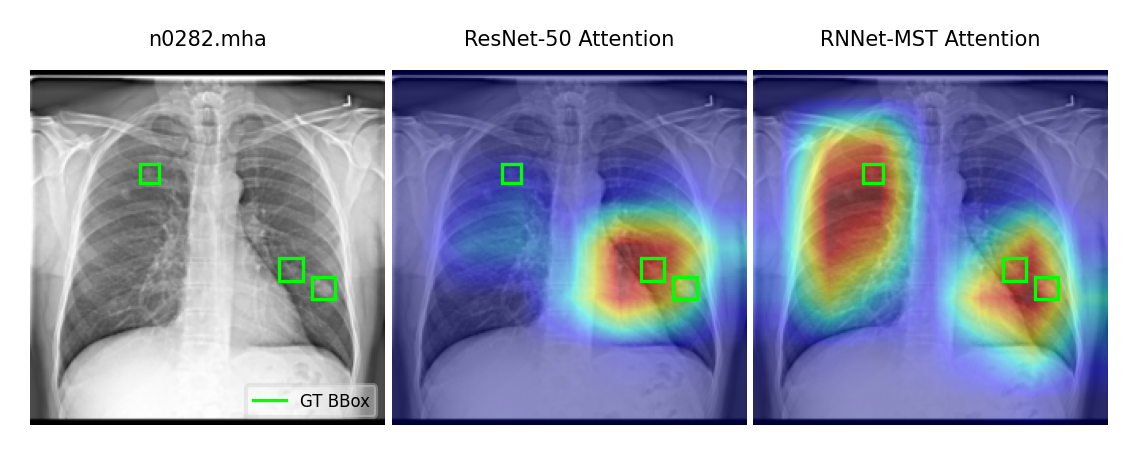

  ✓ Plot shown


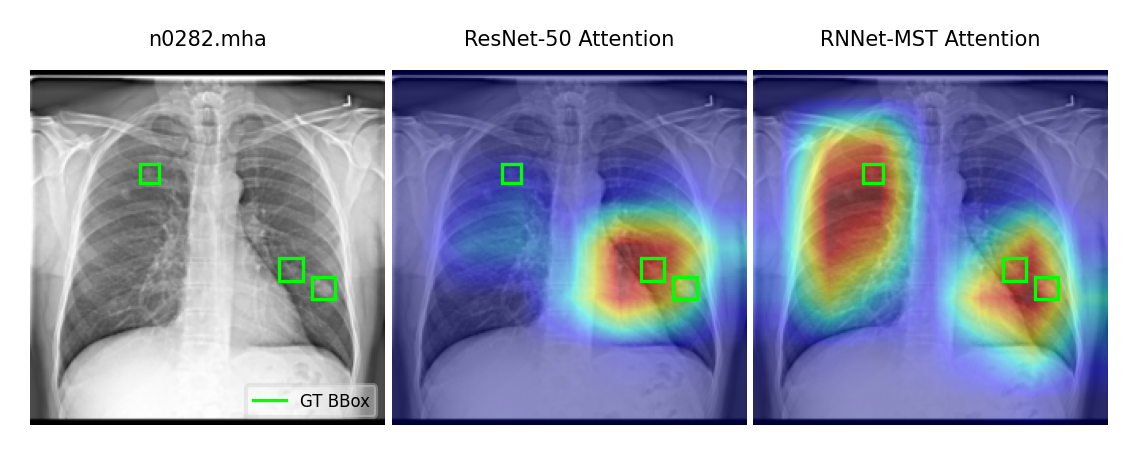

In [21]:
plot_patient_comparison('n0282.mha')


--- plot_patient_comparison: n0368.mha ---
  Finding record for n0368.mha...
  Found at dataset_nodule21\cxr_images\proccessed_data\split_data\test\images\n0368.mha
  sitk.ReadImage...
  ✓ sitk.ReadImage done
  ✓ Image preprocessed, tensor shape=torch.Size([1, 3, 224, 224])
  ✓ 1 bboxes parsed
  Running GradCAM (model_a)...
  ✓ GradCAM done
  Running attention map (model_b)...
  ✓ Attention map done
  Plotting...


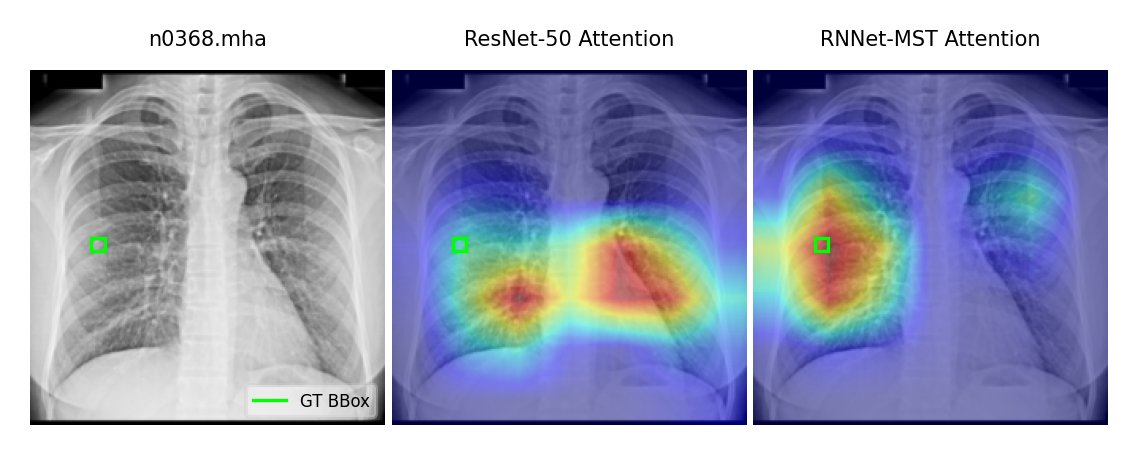

  ✓ Plot shown


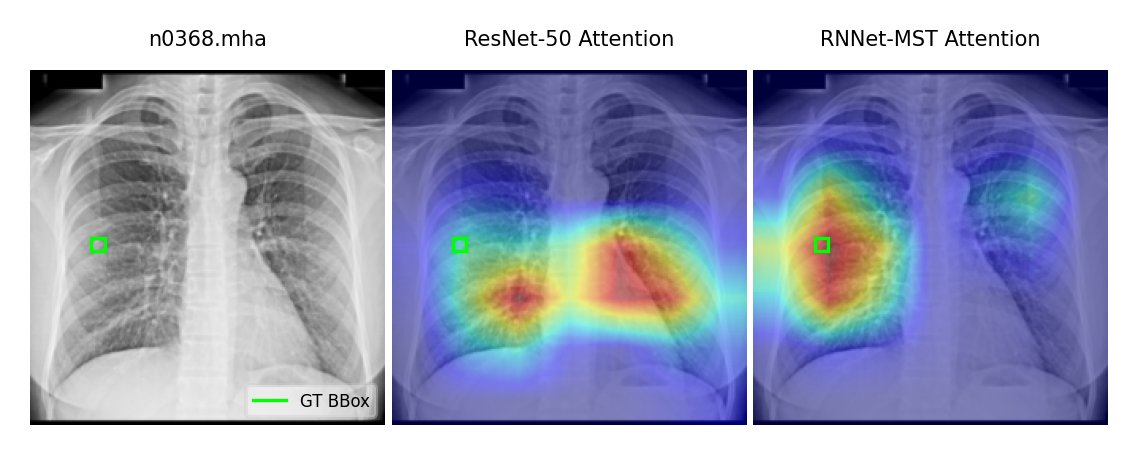

In [22]:
plot_patient_comparison('n0368.mha')